# 02 · Linear regression

Linear regression fits a straight-line relationship
ŷ = w₁x₁ + … + wₚxₚ + b between features and a continuous target. `dolcestat`
can fit it two ways:

- the **closed-form** normal equation — one exact matrix solve, no tuning;
- **gradient descent** — an iterative optimizer that walks downhill on the loss.

We'll fit both on data with *known* coefficients so you can watch the model
recover them.

## The data

We generate 200 points from a known rule — target `y = 2·x1 − 1·x2 + 0.5` plus a
little noise — so we know exactly what a good model should learn. As always,
features and target go into a `DolceSet`.

In [1]:
import numpy as np
import polars as pl

from dolcestat.preprocessing import DolceSet
from dolcestat.linear_models import LinearRegression

rng = np.random.default_rng(0)
n = 200
x1 = rng.normal(0, 1, n)
x2 = rng.normal(0, 1, n)
y = 2.0 * x1 - 1.0 * x2 + 0.5 + rng.normal(0, 0.3, n)   # true: w = [2, -1], b = 0.5

df = pl.DataFrame({"x1": x1, "x2": x2, "y": y})
data = DolceSet()
data.load_from_polars_dataframe(df, target_col="y")

## Closed-form fit (the default)

`LinearRegression` defaults to `optimizer="closed form"`: it solves the normal
equation w = (XᵀX)⁻¹Xᵀy in one shot — no learning rate, no iterations. The fitted
`weights` are the coefficients followed by the intercept.

In [2]:
model = LinearRegression()          # optimizer="closed form"
model.fit(data)

print("weights [w1, w2, b]:", np.round(model.weights, 3))
print("R²:", round(model.predict(data).r2(), 4))

weights [w1, w2, b]: [ 2.02  -0.982  0.503]
R²: 0.9826


## Gradient descent (iterative)

Ask for `optimizer="gradient descent"` and the model fits the *same* line by
repeatedly stepping downhill on the mean-squared-error loss. It lands on
essentially the same coefficients — the difference is we can now watch it get
there. After fitting, `model.optimization` exposes an analyzer over the
optimizer; `plot_loss()` draws the convergence curve.

weights [w1, w2, b]: [ 2.02  -0.953  0.498]
R²: 0.9824


<Axes: title={'center': 'Loss (MSE)'}, xlabel='Iteration', ylabel='Loss'>

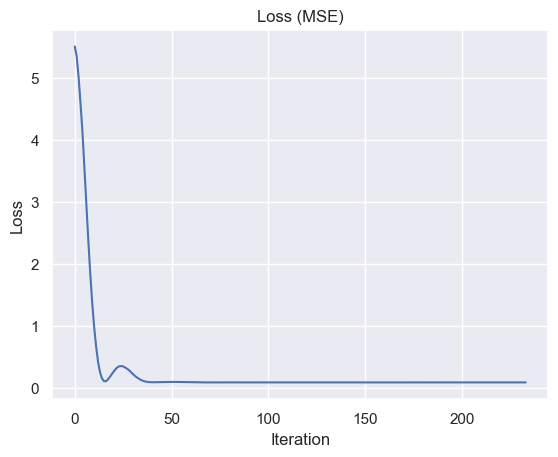

In [3]:
gd_model = LinearRegression("gradient descent")
gd_model.fit(data)

print("weights [w1, w2, b]:", np.round(gd_model.weights, 3))
print("R²:", round(gd_model.predict(data).r2(), 4))

gd_model.optimization.plot_loss()

## Bring your own optimizer

The string shortcuts (`"gradient descent"`, `"newton"`) build an optimizer with
sensible defaults. For full control, construct one yourself and pass the
**instance** — with one rule: leave it **data-less** (don't give it `data`), so
the model can load the training set at `fit` time.

Here we swap the default mini-batch optimizer for full-**batch** gradient descent
with a larger learning rate. The optimizers and all their knobs get their own
deep dive in [`04_optimization`](04_optimization.ipynb).

In [ ]:
from dolcestat.optimization.gradient_descent import GradientDescent

my_optimizer = GradientDescent(loss_function="mse", flavor="batch", alpha=0.3, n_iters=300)
custom_model = LinearRegression(optimizer=my_optimizer).fit(data)

print("R²:", round(custom_model.predict(data).r2(), 4))
print("iterations until convergence:", len(custom_model.optimization.gd.get_loss()))

## Recap

Same model, two fitting routes: an exact closed-form solve and an iterative
optimizer you can inspect and customise. Next we tackle **classification** with
[`03_logistic_regression`](03_logistic_regression.ipynb), where there is no
closed form and the optimizer becomes essential.